In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])

In [3]:
"""initialize the manifolds

Every cell below rebuilds the tangle from scratch with `fresh()`, so the notebook
runs top to bottom without one cell's growth leaking into the next.

`TangleSession` is a drop-in superset of `TangleWorkbench` (every workbench method is
delegated), and it is what owns the resonance-zone helpers used in the last cell.
"""


def fresh():
    """A session with the saddle found, oriented, and both initial segments laid down."""

    session = tanglepack.TangleSession(henon_map, henon_map_inverse)

    # find the fixed point
    fixed_point = session.construct_fixed_point([4, -4])

    # orient the eigenvectors properly
    approx_dirs = {"unstable": np.array([-1, 0]), "stable": np.array([0, 1])}
    session.orient_eigenvectors(fixed_point, approx_dirs)

    # get the initial segments
    session.initialize_both_manifolds(fixed_point)

    return session, fixed_point


session, fixed_point = fresh()

print(f"The fixed point is: {fixed_point.coordinates}")

The fixed point is: [[ 4.31662479 -4.31662479]]


04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


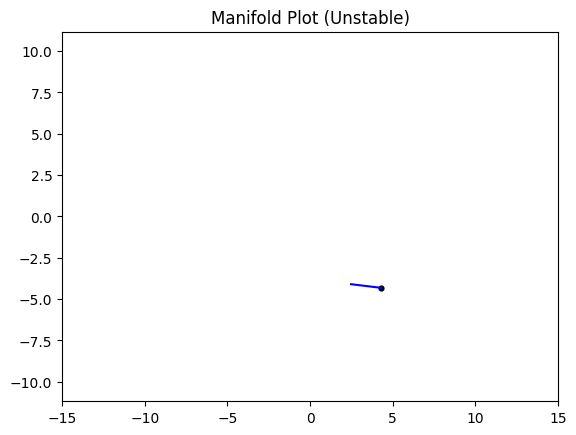

In [4]:
"""growing based on the number of iterates"""

session, fixed_point = fresh()

session.grow_n_times(fixed_point, "unstable", num_iterations=6)
session.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


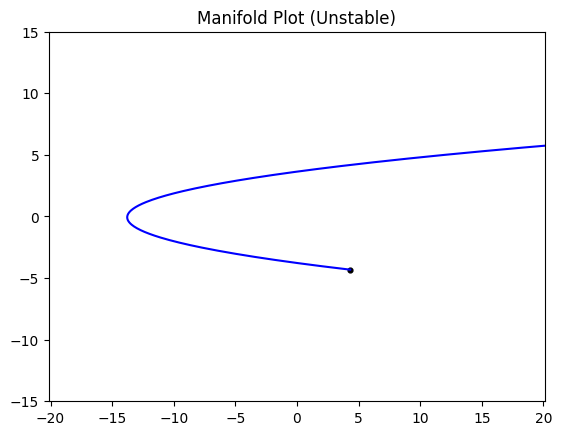

In [5]:
"""growing until the desired cdist is reached"""

session, fixed_point = fresh()

session.grow_until_arclength(fixed_point, "unstable", length=60)
session.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


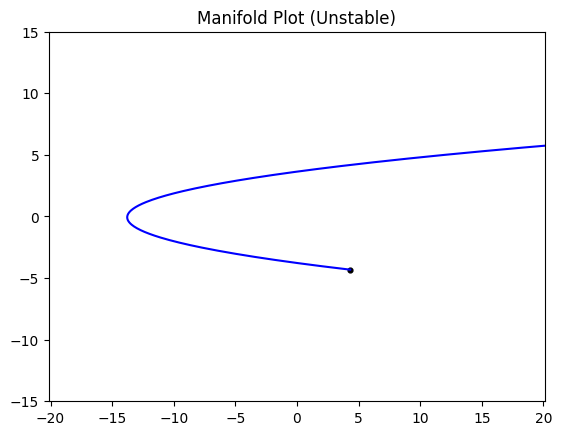

In [6]:
"growing until the manifold turns around"

session, fixed_point = fresh()

session.grow_until_turnaround(fixed_point, "unstable")
session.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:38 INFO     tanglepack.numerics.TangleWorkbench: current intersections 1


04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


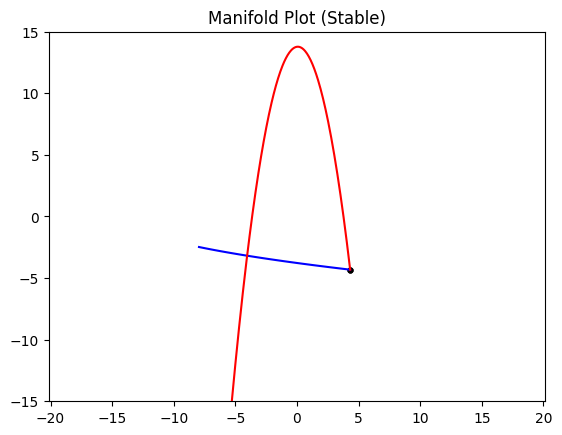

In [7]:
"growing until one manifold intersects the other"

session, fixed_point = fresh()

session.grow_until_turnaround(fixed_point, "stable")
session.grow_until_intersection(fixed_point, "unstable")

session.plot_tangle(fixed_point, "unstable")
session.plot_tangle(fixed_point, "stable", color="r")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


num intersections 4


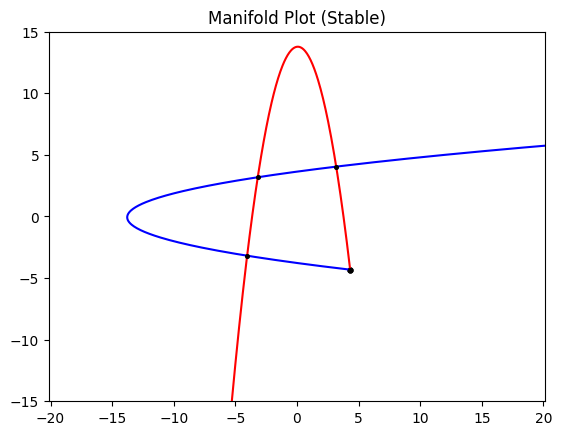

In [8]:
"""growing and computing intersections"""

session, fixed_point = fresh()

session.grow_until_turnaround(fixed_point, "stable")
session.grow_n_times(fixed_point, "unstable", num_iterations=8)

intersections = session.compute_intersections(fixed_point)
print(f"num intersections {len(intersections)}")

session.plot_intersections(fixed_point)
session.plot_tangle(fixed_point, "unstable")
session.plot_tangle(fixed_point, "stable", color="r")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


num bridges 3


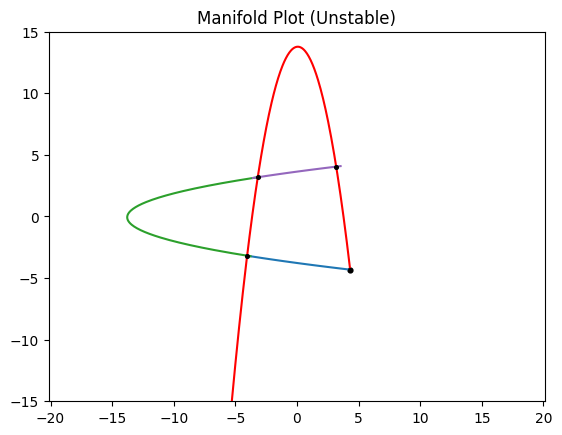

In [9]:
"""growing, computing intersections, and cutting bridges"""

session, fixed_point = fresh()

session.grow_until_turnaround(fixed_point, "stable")
session.grow_n_times(fixed_point, "unstable", num_iterations=8)

intersections = session.compute_intersections(fixed_point)

bridges = session.create_bridges(fixed_point)
print(f"num bridges {len(bridges)}")

session.plot_intersections(fixed_point)
session.plot_tangle(fixed_point, "stable", color="r")
session.plot_all_bridges(bridges)

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()

strong pip candidates: [1, 2, 3]
strong pip 2, zone area 97.9400


04:48:38 WARNING  matplotlib.axes._base: Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


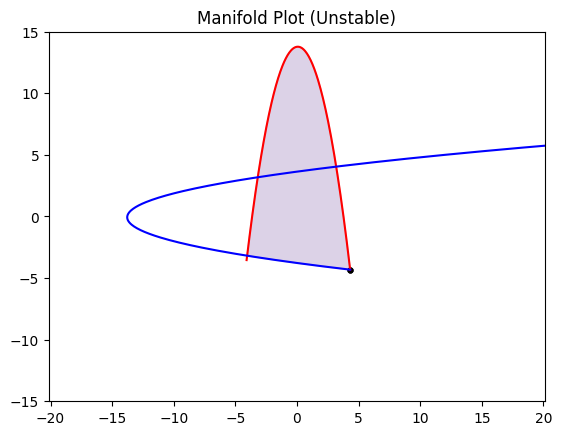

In [10]:
"""computing the resonance zone

`workbench.create_resonance_zone` is gone. A zone is now DEFINED by trimming the
stable manifold at a strong pip, which is a topology-layer decision: build the
trellis, classify its strong pips, then hand the chosen pip id to
`session.resonance_zone` (or `session.add_resonance_zones` for several at once).
"""

session, fixed_point = fresh()

session.grow_until_turnaround(fixed_point, "stable")
session.grow_n_times(fixed_point, "unstable", num_iterations=8)

session.compute_intersections(fixed_point)
session.trim_stable_manifolds(fixed_point)
session.create_bridges(fixed_point)
session.infer_iterate_table()

trellis = session.trellis(fixed_point)
trellis.classify_strong_pips()
print(f"strong pip candidates: {trellis.strong_pip_candidates}")

zone = session.resonance_zone(trellis.strong_pip)
print(f"strong pip {trellis.strong_pip}, zone area {zone.area:.4f}")

session.plot_resonance_zones()
session.plot_tangle(fixed_point, "stable", color="r")
session.plot_tangle(fixed_point, "unstable")

plt.xlim([-15, 15])
plt.ylim([-15, 15])

plt.show()